In [85]:
#Imports

import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

#Data set import and manipulation

x = str(r"winequality-red.csv")

df = pd.read_csv(x, names=["column1"])

#Remove all " marks from the data

row_index = 0 
df.loc[row_index] = df.loc[row_index].str.replace('"', '', regex=False)

df = df["column1"].str.split(";", expand = True)

#Making all data set values floats not strings

df.columns = df.iloc[0]
df = df[1:]
df = df.astype(float)


In [108]:
columns_to_check = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 
    'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 
    'alcohol']

#Function to find anomalies in the data and split them from the main set
def find_anomalies_with_count(df, columns):
    anomalies = pd.DataFrame()
    outlier_counts = {}
    outlier_columns = {}

    for column in columns:
        #Calculate Q1, Q3, and IQR
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        #Define outlier range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        #Find rows where the column value is an outlier
        anomaly_rows = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        #For each anomaly, keep track of the column that caused the outlier
        for idx in anomaly_rows.index:
            if idx in anomalies.index:
                #Append to existing row if already flagged
                outlier_counts[idx] += 1
                outlier_columns[idx].append(column)
            else:
                #New anomaly row
                outlier_counts[idx] = 1
                outlier_columns[idx] = [column]
                anomalies = pd.concat([anomalies, anomaly_rows.loc[[idx]]])

    # Convert dictionaries to Series and add as columns to anomalies DataFrame
    anomalies['Outlier Count'] = anomalies.index.map(outlier_counts)
    anomalies['Outlier Columns'] = anomalies.index.map(outlier_columns)
    
    cleaned_df = df.drop(index=anomalies.index)

    return anomalies, cleaned_df

#Find anomalies in the dataframe
anomalies_df, cdf = find_anomalies_with_count(df, columns_to_check)

print(len(anomalies_df) + len(cdf))


1599


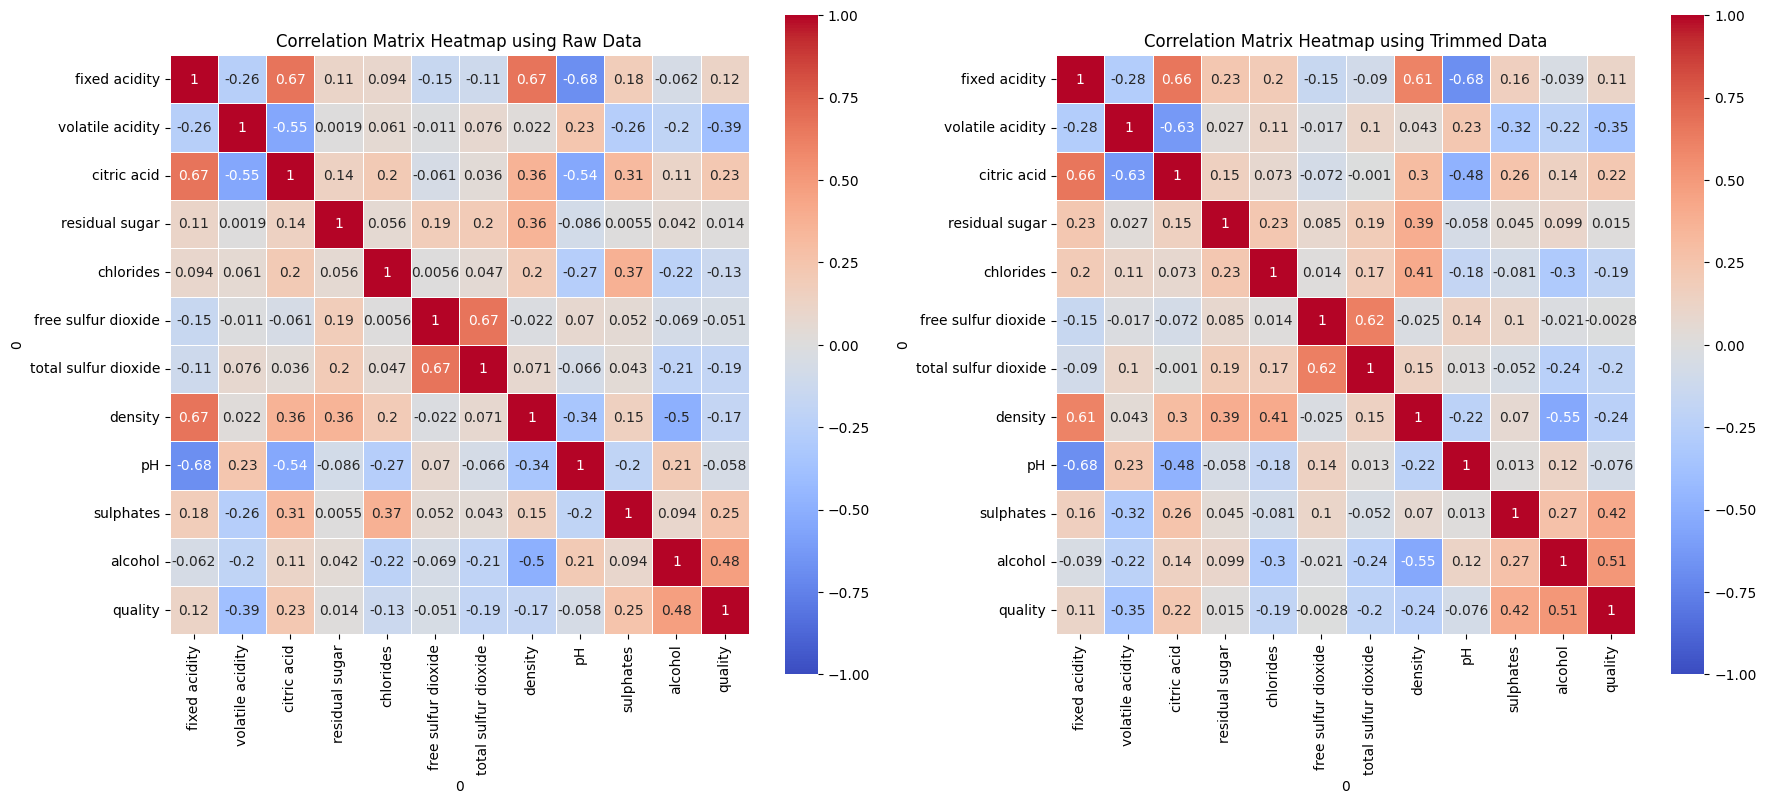

In [87]:
#Calculate the correlation matrices for both dataframes
correlation_matrix_df = df.corr()
correlation_matrix_cdf = cdf.corr()

#Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#Plot the heatmap for the raw data
sns.heatmap(correlation_matrix_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, 
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Matrix Heatmap using Raw Data')

#Plot the heatmap for the trimmed data
sns.heatmap(correlation_matrix_cdf, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, 
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Matrix Heatmap using Trimmed Data')

plt.tight_layout()
plt.show()

In [ ]:
#Set up the training and test data for the trimmed data set, once using all the variables, once using the strongest corelating 2 to quality (sulphates, alcohol)

X = cdf[["fixed acidity","volatile acidity","citric acid","residual sugar",
          "chlorides","free sulfur dioxide","total sulfur dioxide","density",
          "pH","sulphates","alcohol"]].values
y = cdf['quality'].values

#Noramlise data

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

X = np.c_[np.ones(X.shape[0]), X]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

XT = cdf[["sulphates","alcohol"]].values
yT = cdf['quality'].values

XT = (XT - np.mean(XT, axis=0)) / np.std(XT, axis=0)

XT = np.c_[np.ones(XT.shape[0]), XT]

XT_train, XT_test, yT_train, yT_test = train_test_split(XT, yT, test_size=0.2, random_state=17)

In [89]:
#Making linear regression model

class LinearRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.theta = None
    
    def fit(self, c, d):
        self.theta = np.zeros(c.shape[1])
        m = len(d)
        
        #Gradient descent
        for epoch in range(self.epochs):
            gradients = (1/m) * c.T.dot(c.dot(self.theta) - d)
            self.theta -= self.learning_rate * gradients
            
            #Print the cost every 100 epochs
            if epoch % 100 == 0:
                cost = self.compute_cost(c, d)
                print(f'Epoch {epoch}, Cost: {cost}')
    
    def predict(self, c):
        return c.dot(self.theta)
    
    #Errors and cost functions

    def compute_cost(self, c, d):
        m = len(d)
        cost = (1/(2*m)) * np.sum((c.dot(self.theta) - d) ** 2)
        return cost
    def mean_squared_error(self, c_true, d_pred):
        mse = np.mean((c_true - d_pred) ** 2)
        return mse
    
    def root_mean_squared_error(self, d_true, d_pred):
        rmse = np.sqrt(self.mean_squared_error(d_true, d_pred))
        return rmse
    
    def mean_absolute_error(self, d_true, d_pred):
        mae = np.mean(np.abs(d_true - d_pred))
        return mae
    
    def r_squared(self, d_true, d_pred):
        ss_total = np.sum((d_true - np.mean(d_true)) ** 2)
        ss_residual = np.sum((d_pred - d_true) ** 2)
        r2 = 1 - (ss_residual / ss_total)
        return r2

In [90]:
#Generate the model

model = LinearRegression(learning_rate=0.01, epochs=1000)
model.fit(X_train, y_train)

#Predict on the test set

predictions = model.predict(X_test)

print(predictions)

print(y_test)

Epoch 0, Cost: 15.818273112920886
Epoch 100, Cost: 2.2607248846051218
Epoch 200, Cost: 0.4522464548536359
Epoch 300, Cost: 0.2090077095330913
Epoch 400, Cost: 0.17601423902416946
Epoch 500, Cost: 0.17143488975907237
Epoch 600, Cost: 0.17074342368503403
Epoch 700, Cost: 0.1706031315269929
Epoch 800, Cost: 0.17055072984624406
Epoch 900, Cost: 0.17051810302357578
[5.86387967 6.07434443 4.95665426 5.23557615 5.98540405 5.90962144
 5.81655518 6.3117965  5.99010648 5.0386791  4.99880896 6.00138039
 5.74006446 5.71390867 5.91446871 6.07288003 6.53242663 5.62851989
 6.24853035 5.20168338 6.37028063 5.17593939 5.52487704 5.96977297
 6.19966278 5.4357455  4.9222554  5.81729019 6.01724125 5.45314113
 4.88088555 4.92622188 6.05017754 5.67334058 5.91200491 5.40554701
 5.76615908 5.3930468  4.96791767 5.3226145  5.13899001 6.44217792
 6.16788818 6.08103063 5.82470532 5.61592183 5.33725986 5.02681029
 6.38118006 5.08037717 5.13671252 5.41552069 5.77846097 6.04373344
 5.46240223 6.08365327 6.146216   

In [91]:
#Generate the model

modelT = LinearRegression(learning_rate=0.01, epochs=1000)
modelT.fit(XT_train, yT_train)

#Predict on the test set

predictionsT = modelT.predict(XT_test)

print(predictionsT)

print(yT_test)

Epoch 0, Cost: 15.81971474389415
Epoch 100, Cost: 2.2725869282570557
Epoch 200, Cost: 0.4613864375595388
Epoch 300, Cost: 0.21877214062505765
Epoch 400, Cost: 0.18620333172490222
Epoch 500, Cost: 0.18181749422946006
Epoch 600, Cost: 0.18122378302841907
Epoch 700, Cost: 0.18114267859966035
Epoch 800, Cost: 0.18113142315441869
Epoch 900, Cost: 0.1811298190091342
[5.87845483 5.87299666 5.07004674 5.29703169 5.89252459 6.00234195
 5.8339408  6.12370635 5.95719724 5.17986411 5.14080825 5.94312748
 6.2751023  6.1585654  5.80958537 6.04937871 6.30680794 5.60821721
 5.8876971  5.34826526 6.36854514 5.3092094  5.60086699 5.97609448
 6.17746264 5.21891997 4.97114573 5.71803458 6.04265918 5.5800777
 5.05597699 4.99193502 6.23667712 5.64601171 5.93473386 5.74554341
 5.64727307 5.02300998 5.00411273 5.30438191 5.26469537 6.40570895
 5.90722503 5.80706265 5.87678075 5.43309652 5.32936801 4.89429537
 6.2830832  5.08957467 5.24453675 5.26469537 5.89924413 5.80706265
 5.45934399 6.15121518 6.06638392 4

In [92]:
#Errors for the 11 variable data

mse = model.mean_squared_error(y_test, predictions)
rmse = model.root_mean_squared_error(y_test, predictions)
mae = model.mean_absolute_error(y_test, predictions)
r2 = model.r_squared(y_test, predictions)

print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared: {r2}')

#Errors for the 2 variable data

mse = modelT.mean_squared_error(yT_test, predictionsT)
rmse = modelT.root_mean_squared_error(yT_test, predictionsT)
mae = modelT.mean_absolute_error(yT_test, predictionsT)
r2 = modelT.r_squared(yT_test, predictionsT)

print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared: {r2}')

Mean Squared Error (MSE): 0.42557510899540874
Root Mean Squared Error (RMSE): 0.6523611798654245
Mean Absolute Error (MAE): 0.49008884496942884
R-squared: 0.41726733625163637
Mean Squared Error (MSE): 0.4781654872418063
Root Mean Squared Error (RMSE): 0.6914951100635537
Mean Absolute Error (MAE): 0.5173023704537022
R-squared: 0.3452562374930671


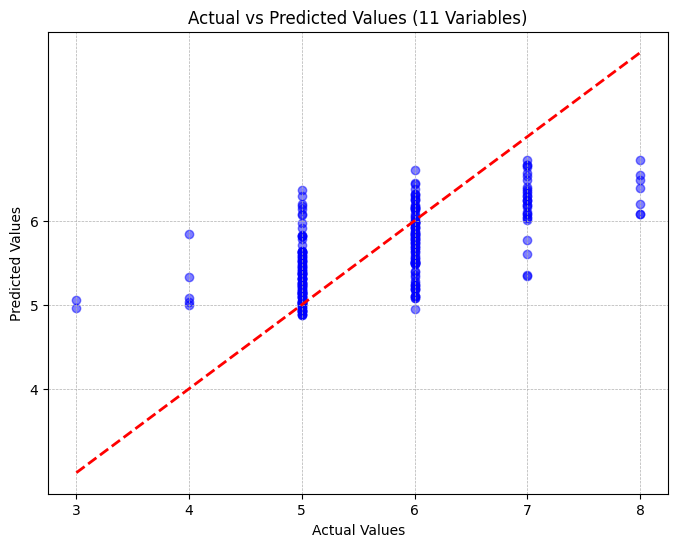

In [110]:
#Plot of actual vs predictions for 11 variables

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (11 Variables)')

#Set gridlines at each integer for better viewing

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(int(y_test.min()), int(y_test.max()) + 1))
plt.yticks(range(int(predictions.min()), int(predictions.max()) + 1))

plt.show()

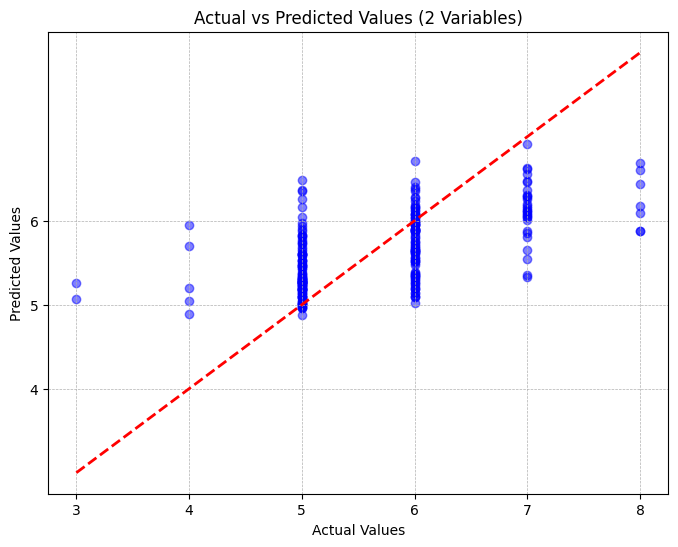

In [112]:
#Plot of actual vs predictions for 2 variables

plt.figure(figsize=(8, 6))
plt.scatter(yT_test, predictionsT, color='blue', alpha=0.5)
plt.plot([yT_test.min(), yT_test.max()], [yT_test.min(), yT_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (2 Variables)')

#Set gridlines at each integer for better viewing

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(int(yT_test.min()), int(yT_test.max()) + 1))
plt.yticks(range(int(predictionsT.min()), int(predictionsT.max()) + 1))

plt.show()

In [95]:
#Resetting data sets for new types of model, same as before

X = cdf[["fixed acidity","volatile acidity","citric acid","residual sugar",
          "chlorides","free sulfur dioxide","total sulfur dioxide","density",
          "pH","sulphates","alcohol"]].values

y = cdf['quality'].values

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

In [109]:
#Fit the ordinal regression model

model = OrderedModel(y_train, X_train, distr='logit')
result = model.fit(method='bfgs')

#Predict the test set

predictions_prob = result.predict(X_test)

#Convert probabilities to the most likely class labels, adjusting for the starting point of y_train to get a more accurate model

Opredictions = np.argmax(predictions_prob, axis=1) + (min(y_train))

#Evaluate the model

accuracy = accuracy_score(y_test, Opredictions)
print(f'Ordinal Regression Accuracy: {accuracy}')

mse = mean_squared_error(y_test, Opredictions)
print(f'Ordinal Regression MSE: {mse}')


Optimization terminated successfully.
         Current function value: 0.874738
         Iterations: 54
         Function evaluations: 56
         Gradient evaluations: 56
Ordinal Regression Accuracy: 0.6108786610878661
Ordinal Regression MSE: 0.502092050209205


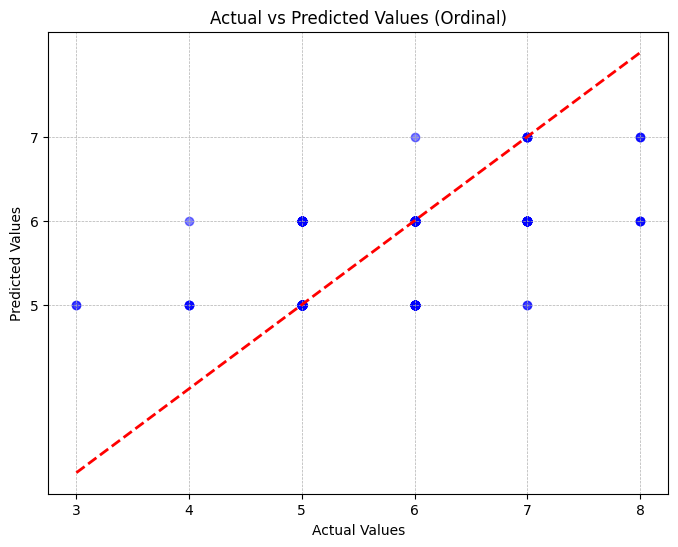

In [97]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, Opredictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Ordinal)')

# Set gridlines at each integer to view better

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(int(y_test.min()), int(y_test.max()) + 1))
plt.yticks(range(int(Opredictions.min()), int(Opredictions.max()) + 1))

plt.show()

In [98]:
#Fit the Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Predict on the test set

rf_predictions = rf_model.predict(X_test)

#Calc errors

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f'Random Forest MSE: {rf_mse}')
print(f'Random Forest RMSE: {rf_rmse}')
print(f'Random Forest MAE: {rf_mae}')
print(f'Random Forest R-Squared: {rf_r2}')

Random Forest MSE: 0.3595493723849373
Random Forest RMSE: 0.5996243593992303
Random Forest MAE: 0.4145188284518828
Random Forest R-Squared: 0.5076752397161761


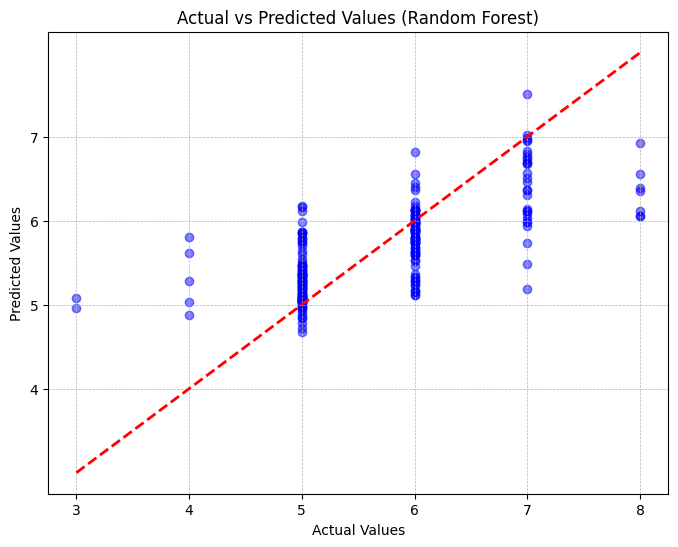

In [99]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Random Forest)')

# Set gridlines at each integer to view better

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(int(y_test.min()), int(y_test.max()) + 1))
plt.yticks(range(int(rf_predictions.min()), int(rf_predictions.max()) + 1))

plt.show()

In [100]:
#Fit the XGBoost Regressor

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

#Predict on the test set

xgb_predictions = xgb_model.predict(X_test)

#Compute errors

xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f'XGBoost MSE: {xgb_mse}')
print(f'XGBoost RMSE: {xgb_rmse}')
print(f'XGBoost MAE: {xgb_mae}')
print(f'XGBoost R-Squared: {xgb_r2}')

XGBoost MSE: 0.36912032999208794
XGBoost RMSE: 0.6075527384450571
XGBoost MAE: 0.40237608514570294
XGBoost R-Squared: 0.49456989237994897


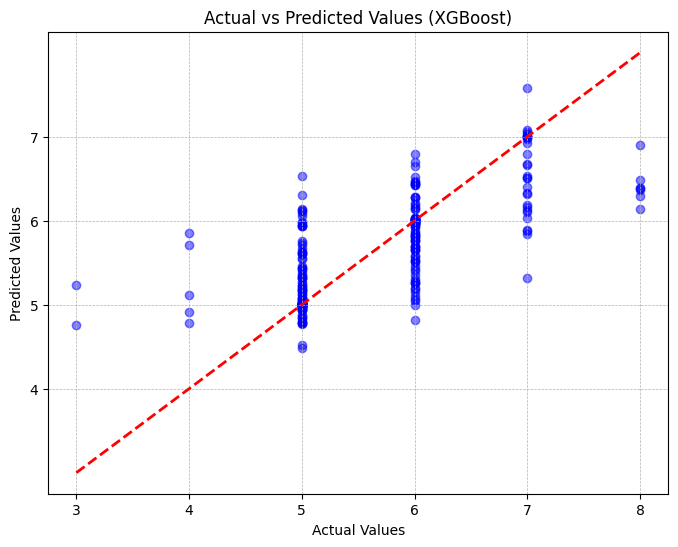

In [101]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (XGBoost)')

# Set gridlines at each integer to view better

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(int(y_test.min()), int(y_test.max()) + 1))
plt.yticks(range(int(xgb_predictions.min()), int(xgb_predictions.max()) + 1))

plt.show()

In [102]:
#Scale the data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Fit the Support Vector Regressor

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)

#Predict on the test set

svr_predictions = svr_model.predict(X_test_scaled)

#Calculate errors

svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_r2 = r2_score(y_test, svr_predictions)

print(f'SVR MSE: {svr_mse}')
print(f'SVR RMSE: {svr_rmse}')
print(f'SVR MAE: {svr_mae}')
print(f'SVR R-Squared: {svr_r2}')

SVR MSE: 0.4312887911694688
SVR RMSE: 0.6567258112557087
SVR MAE: 0.46385189481160494
SVR R-Squared: 0.4094436897020035


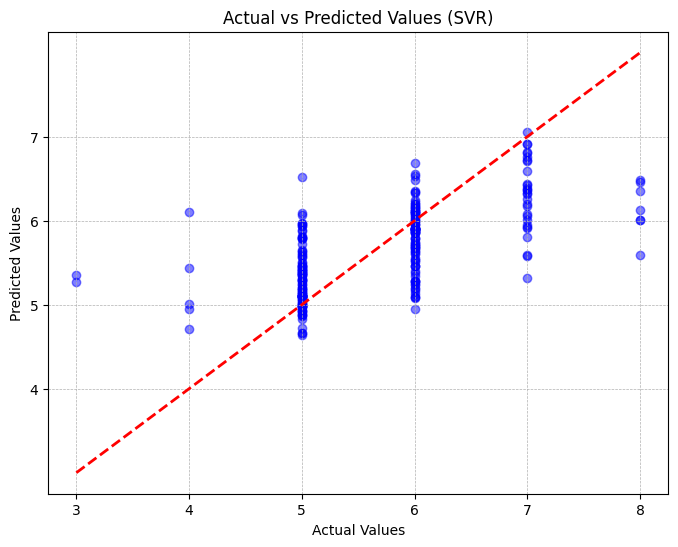

In [103]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, svr_predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (SVR)')

#Set gridlines at each integer for better viewing

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(int(y_test.min()), int(y_test.max()) + 1))
plt.yticks(range(int(svr_predictions.min()), int(svr_predictions.max()) + 1))

plt.show()

In [104]:
#Degree 2 polynomial model

degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_train, y_train)
poly_predictions = poly_model.predict(X_test)
poly_mse = mean_squared_error(y_test, poly_predictions)
poly_rmse = np.sqrt(poly_mse)
poly_mae = mean_absolute_error(y_test, poly_predictions)
poly_r2 = r2_score(y_test, poly_predictions)

#Degree 3 polynomial model

degree = 3
poly3_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly3_model.fit(X_train, y_train)
poly3_predictions = poly3_model.predict(X_test)
poly3_mse = mean_squared_error(y_test, poly3_predictions)
poly3_rmse = np.sqrt(poly3_mse)
poly3_mae = mean_absolute_error(y_test, poly3_predictions)
poly3_r2 = r2_score(y_test, poly3_predictions)

print("\nPolynomial Regression (Degree 2):")
print(f'MSE: {poly_mse}, RMSE: {poly_rmse}, MAE: {poly_mae}, R2: {poly_r2}')

print("\nPolynomial Regression (Degree 3):")
print(f'MSE: {poly3_mse}, RMSE: {poly3_rmse}, MAE: {poly3_mae}, R2: {poly3_r2}')

Epoch 0, Cost: 11.527201060833988
Epoch 100, Cost: 1.6550104731466244
Epoch 200, Cost: 1.1962355149086
Epoch 300, Cost: 0.9329549266277062
Epoch 400, Cost: 0.7541953449119752
Epoch 500, Cost: 0.6247479278544484
Epoch 600, Cost: 0.5278866544612348
Epoch 700, Cost: 0.4538988151385604
Epoch 800, Cost: 0.3965336559052408
Epoch 900, Cost: 0.3515308919176756
Epoch 0, Cost: 10.024698297388559
Epoch 100, Cost: 1.2567237072052013
Epoch 200, Cost: 0.9048136807492503
Epoch 300, Cost: 0.7259074268129049
Epoch 400, Cost: 0.6086628498722837
Epoch 500, Cost: 0.52354311511685
Epoch 600, Cost: 0.4582973031208212
Epoch 700, Cost: 0.4066184662558535
Epoch 800, Cost: 0.36478404949648957
Epoch 900, Cost: 0.330382260529274

Polynomial Regression (Degree 2):
MSE: 1.0049349019930143, RMSE: 1.0024644143275183, MAE: 0.7621751427839646, R2: -0.37604004546799685

Polynomial Regression (Degree 3):
MSE: 1.8476891605427817, RMSE: 1.359297303956269, MAE: 0.9213772773670704, R2: -1.530008930371182


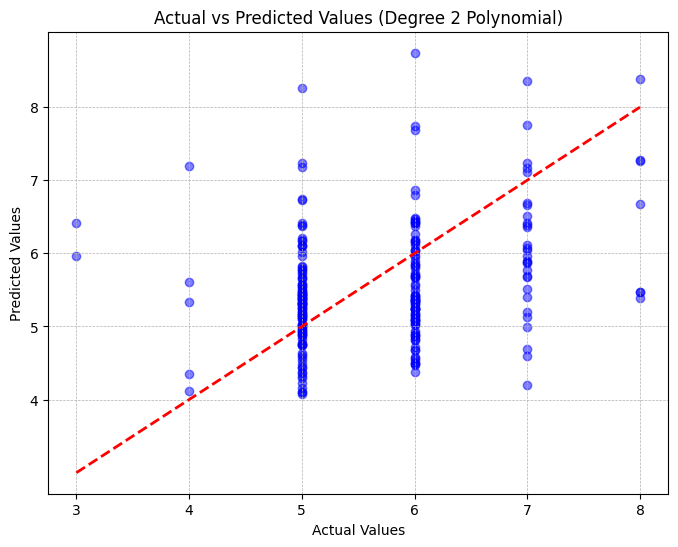

In [105]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, poly_predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Degree 2 Polynomial)')

#Set gridlines at each integer to view better

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(int(y_test.min()), int(y_test.max()) + 1))
plt.yticks(range(int(poly_predictions.min()), int(poly_predictions.max()) + 1))

plt.show()

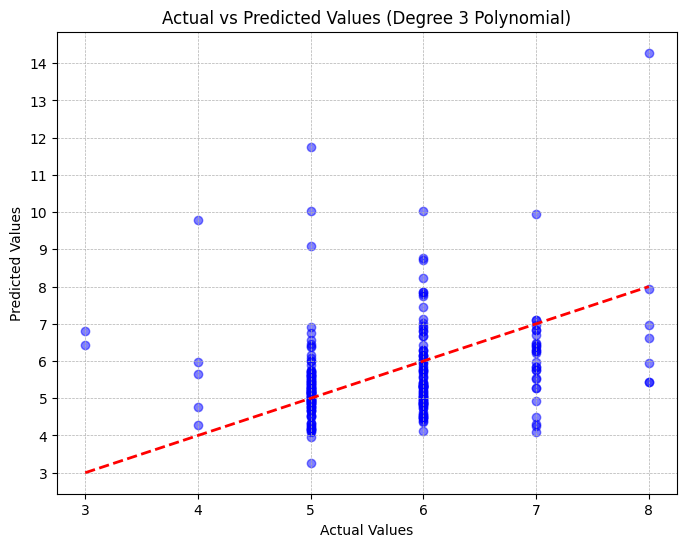

In [106]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, poly3_predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Degree 3 Polynomial)')

#Set gridlines at each integer for better viewing

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(range(int(y_test.min()), int(y_test.max()) + 1))
plt.yticks(range(int(poly3_predictions.min()), int(poly3_predictions.max()) + 1))

plt.show()